In [103]:
##importing relevant libraries 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

In [104]:
###Load the dataset
jan=pd.read_csv("Mall_Customers.csv")

In [105]:
jan.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [106]:
jan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [57]:
jan.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [84]:
jan.shape

(200, 6)

In [58]:
jan.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [59]:
jan.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [60]:
jan.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [85]:
jan.duplicated().sum()
### no duplicates 

np.int64(0)

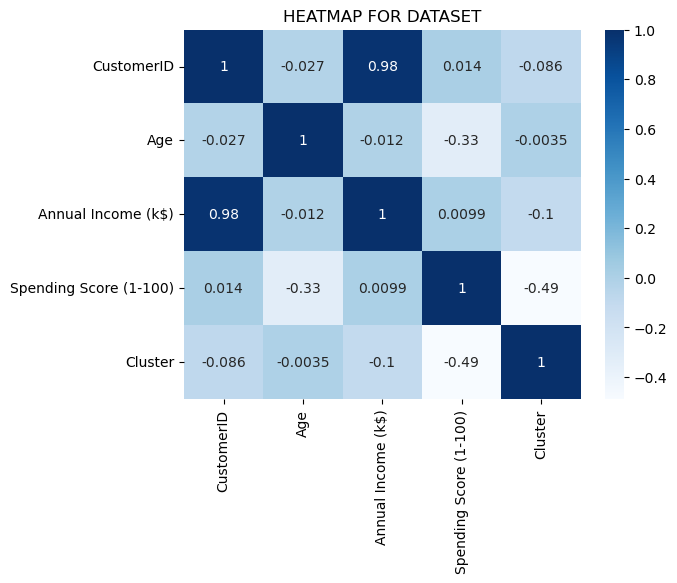

In [82]:
####Visualize distributions and gender counts,correlation,relationship between income and spending

corr= jan.corr(numeric_only=True)
sns.heatmap(corr,
            annot= True,
            cmap="Blues")
plt.title("HEATMAP FOR DATASET")
plt.show()

Cutomer ID vs. Annual Income, they very strong positive correlated and this doesnt mean customer ID causes income
It simply means that as Customer IDs increase, so do the Annual income increases in the Dataset.

Age VrsSpending Score= -0.33
with this, it is moderate negative correlation. It suggests that older customers tend to have slightly lower spending scores.

Notice there are no lineaar relationship between annual income and spending score? Yes, and that is one of the reasons why Clustering is valuable.

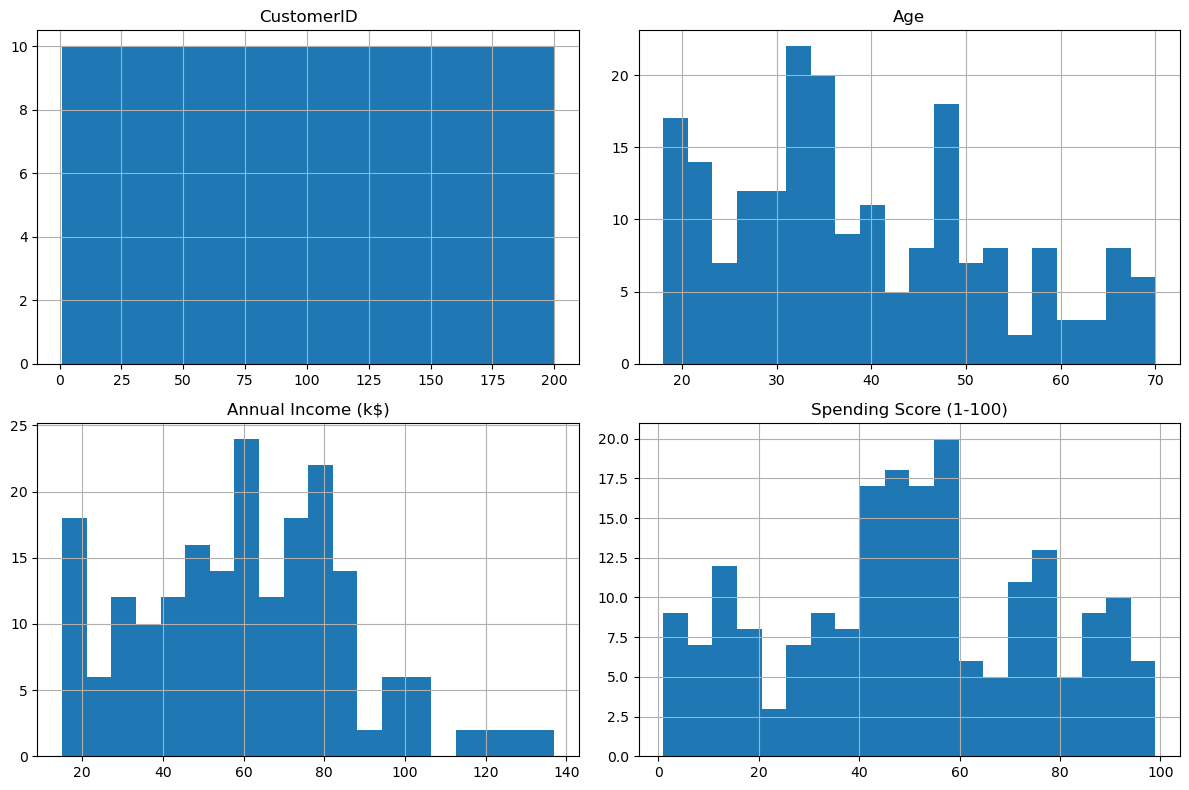

In [63]:
jan.hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

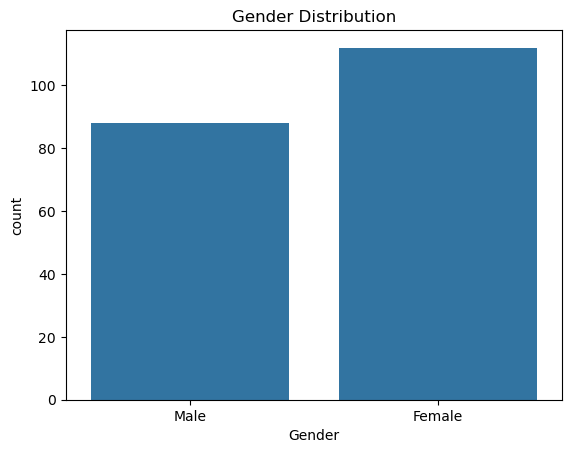

In [64]:
sns.countplot(data=jan, x="Gender")
plt.title("Gender Distribution")
plt.show()

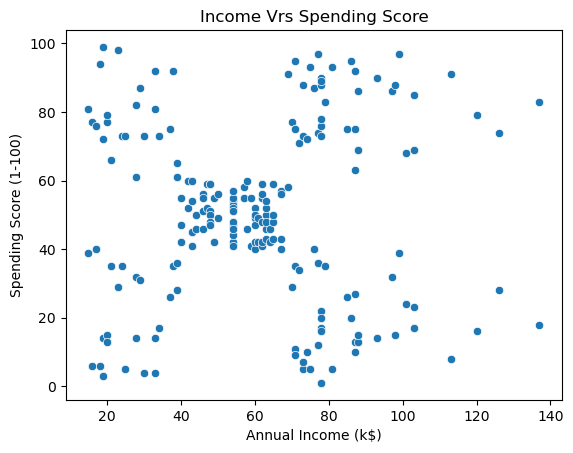

In [87]:
sns.scatterplot(
    data=jan,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)
plt.title("Income Vrs Spending Score")
plt.show()

### A scatter plot of the original dataset which shows us some few clusters

In [66]:
X= jan[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [88]:
### transforming data using the standardScaler transformation.
## we scale before we build our kMeans model because KMeans uses Euclidean distance to measure how close points are.

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [89]:
####Using the elbow method to choose the number of clusters

wcs=[]
for k in range(1,11):
    model= KMeans(
        n_clusters=k,
        random_state=42,
        n_init= 10
    )
    model.fit(X_scaled)
    wcs.append(model.inertia_)

wcss stands for Within- Cluster Sum of Squares, it measures how close the data points are to the center (centriod)
of their assigned cluster.

A smaller Wcss means the cluster are tighter and more compact so therefore the empty list over there just stores the wcss for each number of clusters .

in Cell[89] , I wanted to find the perfect number that will be my k in the range (1,11) and didnt want to randomly choose which might affect the outcomes of my model. So, if the sweet spot k is found, that will be KMeans(n_clusters= 4, or 7) whatever number it could be in that given range. 

Ramdom_state was maintained at 42 just so my code can run again and again without changing my values, that is keeping my initial clusters and typically the same clustering.

n_init=10 tells  how many times with different random starting points and keeps the solution with the lowest wcss which help avoid poor solutions caused by unlucky initial centriods. 

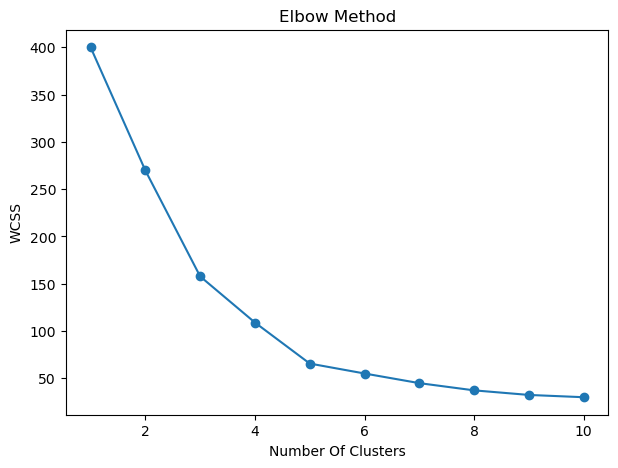

In [69]:
plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcs,marker="o")
plt.xlabel("Number Of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

From the graph, we could see when the dataset was being forced into 1 cluster, the Wcss was very high (400)
then came a large decrease because it was splitted into two clusters.
    It kept being splitted until we notice just small improvement.
Noticeable imporovement ended at k=5.
this means before 5 clusters, each additional cluster greatly improves the clustering and after 5 clustering, the improvement become much smaller.

It is always great to have a lower Wcss that will be k=10 but that will mean splitting your data into 10clusters which might be very difficult to interpretand those samll groups may not be useful.
The Elbow Method aims to find a balance, Low Wcss, reasonable number of clusters,clusters that are easier to interpret.

In [70]:
kmeans= KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
clusters= kmeans.fit_predict(X_scaled)

In [71]:
jan["Cluster"]= clusters
jan.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


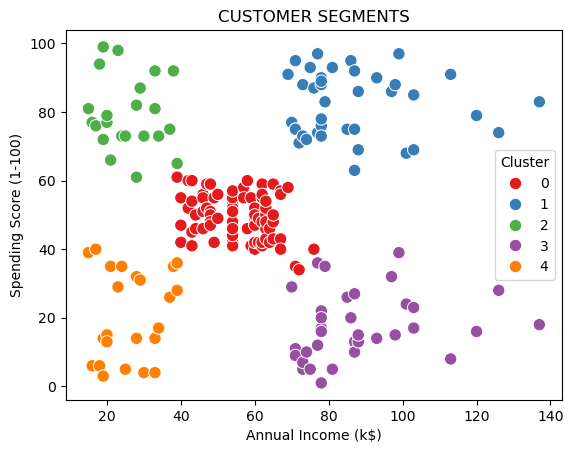

In [73]:
sns.scatterplot(
    data=jan,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=80
)
plt.title("CUSTOMER SEGMENTS")
plt.show()


From the above fig. we can make multiple observations and they include;

Cluster 0: These customers have mid-annual income and their speanding score is mid as well.

Cluster 1: These customers have higher annual income and have higher spending score.

Cluster 2: These customers have low annual income but have a higher spending score .

Cluster 3: These customers have higher annual income but have a lower spending score.

Cluster 4: These customers have a lower annual income and a lower spending score.

In [90]:
centers=scaler.inverse_transform(kmeans.cluster_centers_)
centers
##reversing scaled values into its original values 

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

In [91]:
centers_jan=pd.DataFrame(
    centers,
    columns=[
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)
centers_jan

### numerical way to show you what exactly is happenninh in the graph

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [94]:
## this performance metric measures how well separated and cohesive the clusters are.
silhouette= silhouette_score(X_scaled,clusters)
print("Silhouette Score:", round(silhouette,3))

Silhouette Score: 0.555


In [93]:
##measure the average similarity between each cluster and its most similar neighbour.

db_score= davies_bouldin_score(X_scaled,clusters)
print("Davies-Bouldin Index:",round(db_score,3))

Davies-Bouldin Index: 0.572


In [92]:
##ratio of between cluster to within cluster dispersion.

ch_score=calinski_harabasz_score(X_scaled,clusters)
print("Calinski-Harabasz Index:",round(ch_score,3))

Calinski-Harabasz Index: 248.649


In [96]:
def lookup_customer_cluster():
    customer_id = input("Enter Customer ID: ")
    
    # Look up the customer in the existing dataframe
    # Adjust "CustomerID" to match your actual column name
    match = jan[jan["CustomerID"] == int(customer_id)]
    
    if match.empty:
        print(f"Customer ID {customer_id} not found.")
        return
    
    income = match["Annual Income (k$)"].values[0]
    spending = match["Spending Score (1-100)"].values[0]
    
    # Scale and predict using the fitted scaler/model
    new_data = pd.DataFrame(
        [[income, spending]],
        columns=["Annual Income (k$)", "Spending Score (1-100)"]
    )
    new_data_scaled = scaler.transform(new_data)
    cluster = kmeans.predict(new_data_scaled)[0]
    
    print(f"\nCustomer ID: {customer_id}")
    print(f"Annual Income: ${income}k")
    print(f"Spending Score: {spending}")
    print(f"Cluster: {cluster}")


lookup_customer_cluster()

Enter Customer ID:  199



Customer ID: 199
Annual Income: $137k
Spending Score: 18
Cluster: 3


This Function is to tell us the actual customers who belongs to a particular cluster and what their annual income and spending score is 

In [97]:
cluster_labels = {
    0: "Average Customer",
    1: "Premium Target (High Income, High Spending)",
    2: "Impulsive Spender (Low Income, High Spending)",
    3: "Careful Earner (High Income, Low Spending)",
    4: "Budget Conscious (Low Income, Low Spending)"
}

This Function is almost like the old one, just that this generates a graph showing us where the customer is and doesnt make need to rerun the code before it can be used. You can just pass in q if you wanna quit the function

In [99]:
def lookup_customer_cluster():
    while True:
        customer_id = input("\nEnter Customer ID (or 'q' to quit): ")
        
        if customer_id.lower() == 'q':
            print("Exiting lookup.")
            break
        
        match = jan[jan["CustomerID"] == int(customer_id)]
        
        if match.empty:
            print(f"Customer ID {customer_id} not found. Try again.")
            continue
        
        income = match["Annual Income (k$)"].values[0]
        spending = match["Spending Score (1-100)"].values[0]
        
        new_data = pd.DataFrame(
            [[income, spending]],
            columns=["Annual Income (k$)", "Spending Score (1-100)"]
        )
        new_data_scaled = scaler.transform(new_data)
        cluster = kmeans.predict(new_data_scaled)[0]
        label = cluster_labels[cluster]
        
        print(f"\nCustomer ID: {customer_id}")
        print(f"Annual Income: ${income}k")
        print(f"Spending Score: {spending}")
        print(f"Cluster: {cluster} — {label}")
        
        # Visual overlay
        plt.figure(figsize=(8, 6))
        sns.scatterplot(
            data=jan,
            x="Annual Income (k$)",
            y="Spending Score (1-100)",
            hue="Cluster",
            palette="Set1",
            s=80,
            alpha=0.6
        )
        plt.scatter(
            income, spending,
            color="black", marker="*", s=400,
            label=f"Customer {customer_id}", edgecolor="white", linewidth=1.5
        )
        plt.title(f"Customer {customer_id} — {label}")
        plt.legend()
        plt.show()


lookup_customer_cluster()


Enter Customer ID (or 'q' to quit):  q


Exiting lookup.
